# Stage 8, Part 3: Build and Train Your Own GPT

**Goal:** assemble everything from Parts 1-2 into an actual text-generating model — tokenization, embeddings, positional encoding, stacked causal Transformer blocks — train it on real text, and generate new text with it.

**Dataset:** tinyShakespeare (~1MB of Shakespeare plays, the same corpus used in Karpathy's original char-rnn/nanoGPT projects) — loaded directly from a public URL.

**Tokenization choice:** character-level, not word-level or BPE. This is a deliberate simplification — with a vocabulary of roughly 65 unique characters (letters, punctuation, whitespace), the model has far less to learn than a full subword vocabulary, so it can produce recognizable (if imperfect) Shakespeare-flavored text with a genuinely small model, trained in a reasonable time on a laptop. Real-world GPTs use subword/BPE tokenization (Part 1 mentioned this) — character-level here is a deliberate teaching simplification, not the production approach.

## 1. Load the text and build a character-level vocabulary

Guiding question: how does a character-level vocabulary compare in SIZE to Part 1's word-level vocabulary (capped at 5,000)? What's the tradeoff — a smaller vocabulary makes each individual prediction easier (fewer choices), but what does it cost you in sequence length for the same amount of text?

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

# TODO: download the text (urllib.request.urlopen(url).read().decode('utf-8')), print its length and first 300 characters

data = (urllib.request.urlopen(url).read().decode('utf-8'))
#print(data[:300])
print(len(data))

1115394


In [ ]:
# TODO: build the character vocabulary: chars = sorted(list(set(text))), vocab_size = len(chars)
# TODO: char_to_idx = {ch: i for i, ch in enumerate(chars)}, idx_to_char = {i: ch for i, ch in enumerate(chars)}
# print vocab_size and the actual character list, so you can see exactly what's in it

chars = sorted(list(set(data)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print("Vocabulary size:", vocab_size)
print("Characters:", chars)






Vocabulary size: 65
Characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i', 48: 'j', 49: 'k', 50: 'l', 51: 'm', 52: 'n', 53: 'o', 54: 'p', 55: 'q', 56: 'r', 57: 's', 58: 't', 59: 'u', 60: 'v', 61: 'w', 62: 'x', 63: 'y', 64: 'z'}


## 2. Encode the full text and split into train/val

Convert the entire text into one long tensor of integer IDs (one per character). Since this is one continuous document (not separate labeled examples like Titanic or spam), the split is simply: first ~90% of characters for training, last ~10% for validation — a straightforward chronological split, not row-by-row.

In [17]:
# TODO: encode the full text: data = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)
# TODO: split ~90/10: n = int(0.9 * len(data)); train_data = data[:n]; val_data = data[n:]


encoded_data = torch.tensor(
    [char_to_idx[c] for c in data],
    dtype=torch.long
)

n = int(0.9 * len(encoded_data))

train_data = encoded_data[:n]
val_data = encoded_data[n:]




## 3. Building training batches: predicting the NEXT character

GPT-style models are trained on one task: given some characters, predict the next one. A training example is just a chunk of `block_size` consecutive characters (input) and the same chunk shifted one position to the right (target).

**Concretely:** if `block_size=8` and your chunk is `"hello wo"`, the input is `"hello wo"` and the target is `"ello wor"` — at every position, the target is simply "the next character." This gives you `block_size` separate next-character predictions packed into a single training example, for free.

**Syntax note:** randomly sample starting positions across the full training data for each batch, rather than walking through sequentially — this is standard practice for this kind of training and gives more varied batches.

In [29]:
block_size = 64   # how many characters of context the model sees at once
batch_size = 32

def get_batch(data, block_size, batch_size):
    # TODO: randomly pick `batch_size` starting indices (ix = torch.randint(0, len(data) - block_size, (batch_size,)))
    # TODO: x = stack of data[i:i+block_size] for each i in ix
    # TODO: y = stack of data[i+1:i+block_size+1] for each i in ix  -- shifted by 1, the "next character" targets
    # return x, y
    ix = torch.randint(0, len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x,y


# TODO: test it -- get one batch from train_data, print its shape, and decode the first example back to text
# to confirm the input/target relationship makes sense (target should read as input shifted by one character)

x, y = get_batch(train_data, block_size, batch_size)

print(x.shape)
print(y.shape)
#print(''.join(idx_to_char[i.item()] for i in x[0]))
print("#"*70)
print(''.join(idx_to_char[i.item()] for i in y[0]))


torch.Size([32, 64])
torch.Size([32, 64])
######################################################################
 like your silence, it the more shows off
Your wonder: but yet s


## 4. The GPT model — reusing your Part 2 TransformerBlock

Architecture: character IDs → embedding + positional encoding → several stacked TransformerBlocks (each with causal masking) → final linear layer projecting back to vocabulary size (one score per possible next character) → softmax (handled by the loss function, same pattern as Stage 7/8 so far).

**Syntax note:** unlike Part 2's toy example (a fixed 4-token input), here the causal mask needs to be built fresh for whatever `block_size` you're actually using, and passed into EVERY stacked block — every layer needs the same masking, or information could still leak forward through an unmasked layer.

In [30]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=32):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.feedforward = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        attn_output, _ = self.attention(x, x, x, attn_mask=mask)
        x = self.norm1(x + attn_output)     #     -- residual connection, then normalize
        ff_output = self.feedforward(x)
        x = self.norm2(x + ff_output)          #    -- residual connection, then normalize
        return x


In [31]:
def positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class MiniGPT(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        n_heads=4,
        n_layers=4,
        block_size=64
    ):
        super().__init__()

        self.block_size = block_size
        self.d_model = d_model

        # Character ID → learned embedding vector
        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # Stack multiple Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads)
            for _ in range(n_layers)
        ])

        # Convert final representation → vocabulary logits
        self.final_layer = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)
        seq_len = x.shape[1]

        # Token embeddings
        # (batch, seq_len)
        #       ↓
        # (batch, seq_len, d_model)
        token_emb = self.token_embedding(x)

        # Positional information
        # (seq_len, d_model)
        pos_emb = positional_encoding(
            seq_len,
            self.d_model
        ).to(x.device)

        # Combine WHAT the token is + WHERE it is
        h = token_emb + pos_emb

        # Causal mask:
        # prevent each token from looking into the future
        mask = torch.triu(
            torch.ones(seq_len, seq_len),
            diagonal=1
        ) * -1e9

        # Pass through Transformer blocks
        for block in self.blocks:
            h = block(h, mask=mask)

        # Convert representations into predictions
        # (batch, seq_len, d_model)
        #       ↓
        # (batch, seq_len, vocab_size)
        logits = self.final_layer(h)

        return logits


## 5. Training loop

**Syntax note on the loss:** `nn.CrossEntropyLoss` expects a 2D input of shape `(N, vocab_size)` and a 1D target of shape `(N,)` — but your model outputs `(batch, seq_len, vocab_size)` and targets are `(batch, seq_len)`. Reshape both by flattening the batch and sequence dimensions together before computing loss: `logits.view(-1, vocab_size)` and `targets.view(-1)`. This treats every character-position across the whole batch as one big flat set of independent next-character predictions.

In [32]:
import torch.optim as optim
import torch.nn as nn

model = MiniGPT(
    vocab_size=vocab_size,
    d_model=128,
    n_heads=4,
    n_layers=4,
    block_size=block_size
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4
)

n_steps = 3000
loss_history = []

for step in range(n_steps):

    # Get random training examples
    x, y = get_batch(
        train_data,
        block_size,
        batch_size
    )

    # Forward pass
    logits = model(x)

    # Compute loss
    loss = criterion(
        logits.view(-1, vocab_size),
        y.view(-1)
    )

    # Clear old gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Record loss
    loss_history.append(loss.item())

    # Print progress
    if step % 200 == 0:
        print(f"Step {step}: loss = {loss.item():.4f}")

Step 0: loss = 4.3298
Step 200: loss = 2.4998
Step 400: loss = 2.3506
Step 600: loss = 2.2082
Step 800: loss = 2.0739
Step 1000: loss = 2.0424
Step 1200: loss = 2.0148
Step 1400: loss = 1.8855
Step 1600: loss = 1.8747
Step 1800: loss = 1.7808
Step 2000: loss = 1.8230
Step 2200: loss = 1.8418
Step 2400: loss = 1.7231
Step 2600: loss = 1.8191
Step 2800: loss = 1.7392


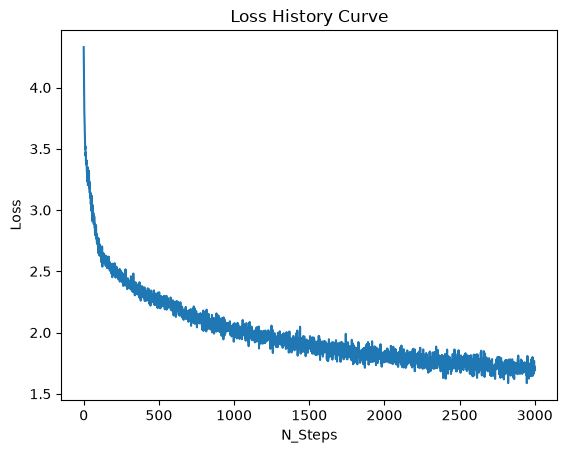

In [33]:
# TODO: plot the loss curve

import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("N_Steps")
plt.ylabel("Loss")
plt.title("Loss History Curve")
plt.show()



## 6. Text generation — sampling strategies

To generate text: start with some initial characters (a "prompt"), predict a probability distribution over the next character, pick one, append it, and repeat — feeding the model's own output back in as input for the next step. This is autoregressive generation, the direct practical payoff of causal masking: the model was trained to only ever look backward, so generating one step at a time is exactly what it's built for.

**Three ways to pick the next character from the predicted probability distribution:**
- **Greedy:** always pick the single highest-probability character. Deterministic, but tends to produce repetitive, boring text.
- **Temperature sampling:** divide the logits by a temperature value BEFORE softmax. Temperature < 1 sharpens the distribution (more confident, closer to greedy); temperature > 1 flattens it (more random, more diverse, more mistakes).
- **Top-k sampling:** only consider the k most likely next characters, zero out everything else, then sample from that reduced set. Prevents the model from ever picking a wildly unlikely character, while still allowing some randomness among reasonable choices.

**Syntax note:** `torch.multinomial(probs, num_samples=1)` samples an index according to a probability distribution — higher-probability options are more likely to be picked, but it's not deterministic like `argmax`.

In [35]:
def generate(model, prompt, max_new_tokens=200, temperature=1.0, top_k=None):
    model.eval()

    # Encode prompt into character IDs
    ids = [char_to_idx[c] for c in prompt]
    x = torch.tensor(ids, dtype=torch.long).unsqueeze(0)

    for _ in range(max_new_tokens):

        # Only keep the most recent block_size characters
        if x.shape[1] > block_size:
            x_cond = x[:, -block_size:]
        else:
            x_cond = x

        # Get model predictions
        logits = model(x_cond)

        # Only care about the final position
        logits = logits[:, -1, :]

        # Apply temperature
        logits = logits / temperature

        # Apply top-k filtering
        if top_k is not None:
            threshold = torch.topk(logits, top_k)[0][:, -1]
            logits[logits < threshold] = float('-inf')

        # Convert logits to probabilities
        probs = torch.softmax(logits, dim=-1)

        # Sample next character
        next_id = torch.multinomial(probs, num_samples=1)

        # Append next character ID
        x = torch.cat([x, next_id], dim=1)

    # Decode IDs back into characters
    generated = ''.join(
        idx_to_char[i.item()]
        for i in x[0]
    )

    return generated

In [41]:
# TODO: generate text with a few different settings and compare:
generate(model, prompt="ROMEO:", temperature=0.5)  # -- more conservative
##generate(model, prompt="ROMEO:", temperature=1.0)  # -- default
#generate(model, prompt="ROMEO:", temperature=1.5)  # -- more chaotic
#generate(model, prompt="ROMEO:", temperature=1.0, top_k=10) # -- constrained randomness


'ROMEO:\nThe his for for his is so most so be the come\nThe well the shall not brother the dearth the hath streess in the\nshe were you hold and I have make and are hearth,\nThe and where had hears is out make c'

## 7. Honest evaluation

This is a small model (128-dim embeddings, 4 layers, character-level) trained briefly on ~1MB of text — it will NOT produce coherent Shakespeare. What you should realistically expect: recognizable word-like structures, correct spacing and punctuation patterns, character names and stage-direction formatting ("ROMEO:", line breaks), but largely nonsensical content beyond a few words.

Guiding question: compare your temperature=0.5 and temperature=1.5 outputs directly. Does higher temperature visibly produce more spelling/structure errors in exchange for more "creative" (less repetitive) text? This tradeoff — coherence vs. diversity — is a real, practical consideration in production LLM systems (it's the same "temperature" parameter you may have seen exposed in ChatGPT-style API settings).

High temperature produces more spelling and structure errors in exchange for creativity. I observed that with lower temperature it is more repetitive but the sentence structure has some sort of meaning behind it, the words are spelled correctly, the structure is there.

## Wrap-up

Write a short summary:
- Walk through the full pipeline, start to finish, in your own words: raw text → ... → generated text. Name every stage.
- What's the single biggest lever you'd pull to improve output quality if you had more compute/time — more layers, bigger d_model, more training steps, more data, or switching to subword tokenization? Justify your choice.
- You built this same TransformerBlock in Part 2 on a 4-token toy example, and it's now powering actual text generation on real Shakespeare. What, if anything, actually changed between those two uses — and what does that tell you about how "scaling up" a Transformer architecture works in practice?

1) Start with raw text
2) Build character level vocab list
3) Encode the full text into unique IDs
4) Split the training/val data
5) character IDs → embedding + positional encoding → several stacked TransformerBlocks -> final linear layer → softmax
6) Train the model
7) Evaulate the model & generate text


- I think the biggest lever I would pull is to create more layers and use a bigger d_model, which will both add depth and capacity on training volume even more so. Tokenization on subwords instead of char words would not do much to this model, it will only require us to use less tokens to represent the same meaning, which does not help with the overall arching idea of improving this model's coherent-ness.

- Stacking N blocks instead of just one (more depth/capacity). Adding the final linear + softmax layer projecting to vocabulary size (Part 2 never needed this — the toy example just checked output shapes). A real training objective — next-token prediction on actual text, versus Part 2's untrained toy tensors. The autoregressive generation loop — repeatedly sampling and feeding output back in, which Part 2 never did at all.


